## PromptPerfect
 - https://chatgpt.com/g/g-0QDef4GiE-prompt-perfect
 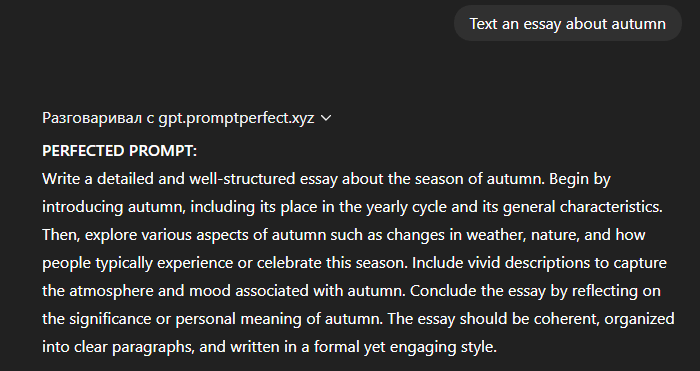

## Promptim
- %pip install promptim

Вот пример настройки и вызова оптимизации промпта через библиотеку Promptim для задачи генерации твитов. Основные этапы — это установка, создание задачи, описание оценки качества и запуск цикла оптимизации.

### 🛠️ Шаг 1: Установка и настройка
Установите библиотеку и настройте окружение для работы с LangSmith (платформой для управления датасетами и промптами):
```bash
pip install -U promptim
```
Убедитесь, что в переменных окружения задан `LANGSMITH_API_KEY`. Для примера используется модель Claude от Anthropic.

### 📁 Шаг 2: Создание конфигурации задачи
Создайте структуру проекта и файл конфигурации `config.json`:
```
my-tweet-task/
├── config.json
└── task.py
```

**`config.json`**: Задает путь к описанию задачи и модель для оптимизатора.
```json
{
  "optimizer": {
    "model": {
      "model": "claude-3-5-sonnet-20241022",
      "max_tokens_to_sample": 8192
    }
  },
  "task": "examples/tweet_writer/task.py:tweet_task"
}
```

### 📝 Шаг 3: Описание задачи и оценщика (Evaluator)
В файле `task.py` определяется сама задача: датасет, начальный промпт и функции оценки.

**`task.py`**:
```python
from langsmith.schemas import Run, Example

def tweet_omits_hashtags(run: Run, example: Example) -> dict:
    """Evaluator: penalizes tweets with hashtags."""
    predicted_content = str(run.outputs.get("output", ""))
    # Оценка: 1 балл, если хештегов нет, 0 — если есть
    score = int("#" not in predicted_content)
    return {
        "key": "tweet_omits_hashtags",
        "score": score,  # Больше — лучше
        "comment": "Pass: tweet omits hashtags" if score == 1 else "Fail: omit all hashtags from generated tweets",
    }

# Определение задачи
tweet_task = {
    "name": "Tweet Generator",
    "dataset": "tweet-optim",  # Имя датасета в LangSmith
    "initial_prompt": {
        "identifier": "tweet-generator-example:c39837bd",  # Промпт из LangSmith Hub
    },
    "evaluators": [tweet_omits_hashtags],  # Список функций-оценщиков
    "evaluator_descriptions": {
        "tweet_omits_hashtags": "Checks if the tweet contains no hashtags. 1 if true, 0 if false.",
    },
    "description": "Generate engaging tweets on various topics without using hashtags.",
}
```
**Ключевые компоненты задачи:**
| Компонент | Описание | Пример/Значение |
| :--- | :--- | :--- |
| **Датасет** | Набор примеров в LangSmith для обучения и оценки. | `"tweet-optim"` |
| **Начальный промпт** | Исходный шаблон для оптимизации. | Идентификатор в LangSmith Hub. |
| **Оценщики (Evaluators)** | Функции, возвращающие `score` (чем больше, тем лучше). | Проверка на отсутствие хештегов. |
| **Оптимизатор** | Модель LLM (например, Claude), которая переписывает промпт. | `claude-3-5-sonnet`. |

### 🚀 Шаг 4: Запуск оптимизации
Запустите процесс оптимизации через CLI. Promptim будет итеративно улучшать промпт на основе оценок.
```bash
promptim train --task ./my-tweet-task/config.json --epochs 5
```
**Что происходит при выполнении команды:**
1.  **Базовый замер**: Исходный промпт оценивается на датасете.
2.  **Цикл оптимизации**:
    *   Promptim использует LLM-оптимизатор для создания новой версии промпта.
    *   Новая версия тестируется на **тренировочных** примерах.
    *   Если средний балл на **валидационных** данных вырос, новая версия сохраняется.
3.  **Результат**: В терминал выводится улучшенный промпт, а также ссылка на его сохраненную версию в LangSmith Hub.

### 🔍 Расширенные возможности
*   **Обратная связь от человека**: Можно добавить этап ручной проверки через **очередь аннотаций (annotation queue)** в LangSmith.
    ```bash
    promptim train --task ./config.json --annotation-queue "my_feedback_queue"
    ```
*   **Несколько оценщиков**: В `evaluators` можно передать список функций, чтобы оптимизировать промпт по нескольким критериям одновременно (например, длина, стиль, содержание).

### ⚖️ Promptim и другие инструменты
Promptim фокусируется на **точечной оптимизации одного промпта**, оставляя человека в цикле для контроля. Это отличает его от таких фреймворков, как **DSPy**, которые автоматически оптимизируют **целые конвейеры (pipeline)** из нескольких модулей, больше полагаясь на автоматизацию.

| Критерий | Promptim | DSPy (для сравнения) |
| :--- | :--- | :--- |
| **Объект оптимизации** | Один текст промпта. | Конвейер из нескольких модулей (сигнатур). |
| **Роль человека** | Встроена: ручная оценка через очереди, просмотр промптов в Hub. | Сведена к минимуму, акцент на полной автоматизации. |
| **Основной метод** | Итеративное переписывание промпта LLM-оптимизатором. | Подбор инструкций и few-shot примеров с помощью оптимизаторов (MIPRO, Bootstrap). |

### 💎 Рекомендации и выводы
1.  **Начните с простого**: Создайте небольшой, но репрезентативный датасет в LangSmith и один четкий оценщик, как в примере выше.
2.  **Используйте человеческую проверку**: Функция `--annotation-queue` помогает корректировать автоматическую оптимизацию.
3.  **Интерпретируйте результаты**: Все версии промптов и история их оценок сохраняются в LangSmith — анализируйте их, чтобы понять логику улучшений.

Promptim — это **экспериментальная библиотека**, которая хорошо подходит для систематического улучшения отдельных промптов, когда у вас есть четкие критерии оценки (датасет и evaluator). Если же ваша задача требует оптимизации сложного многомодульного конвейера, стоит рассмотреть такие инструменты, как **DSPy**.

Если вы хотите, я могу подробнее разобрать:
*   Как создать и подготовить датасет для оптимизации в LangSmith.
*   Пример более сложного оценщика (evaluator) с использованием LLM-as-a-judge.
*   Практические стратегии для предотвращения переобучения (overfitting) промпта на датасете.

## DSPy
- pip install dspy

In [ ]:
!pip install dspy

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
import dspy
from dspy.teleprompt import MIPROv2
from dspy.evaluate import Evaluate

# 1. Определяем сигнатуру задачи
class SentimentClassifier(dspy.Signature):
    """Определи тональность текста как 'позитивный' или 'негативный'."""
    text = dspy.InputField()
    sentiment = dspy.OutputField(desc="Одно слово: позитивный или негативный")

# 2. Конфигурируем языковую модель
lm = dspy.LM(model="gpt-4o-mini", api_key=os.environ['OPENAI_API_KEY'])
dspy.configure(lm=lm)

# 3. Подготавливаем данные
trainset = [
    dspy.Example(text="Обожаю этот фильм!", sentiment="позитивный").with_inputs("text"),
    dspy.Example(text="Это было ужасное обслуживание.", sentiment="негативный").with_inputs("text"),
    dspy.Example(text="Сейчас оборжусь.", sentiment="позитивный").with_inputs("text"),
    # ... больше примеров
]
devset = [
    dspy.Example(text="Как же актерище просто!", sentiment="негативный").with_inputs("text"),
    dspy.Example(text="Неприятно", sentiment="негативный").with_inputs("text"),
    dspy.Example(text="Не знаю, что сказать о нем, но пойдет.", sentiment="позитивный").with_inputs("text"),
]  # Валидационный набор

# 4. Определяем метрику для оценки
def sentiment_metric(example, pred):
    # Сравниваем предсказание с эталонным ответом
    return int(example.sentiment.lower() == pred.sentiment.lower())

# 5. Создаем исходную программу
program = dspy.Predict(SentimentClassifier)

# 6. Инициализируем и запускаем оптимизатор MIPROv2
teleprompter = MIPROv2(
    metric=sentiment_metric,
    prompt_model=lm,  # Модель для генерации промптов
    task_model=lm,    # Модель для выполнения задачи
    num_candidates=2,
    auto=None
)

print("🚀 Начинаю оптимизацию с MIPROv2...")
optimized_program = teleprompter.compile(
    program,
    trainset=trainset,
    valset=devset,
    max_bootstrapped_demos=2, # Макс. число сгенерированных few-shot примеров
    max_labeled_demos=2,
    num_trials=3,
    minibatch=False
)

# 7. Используем оптимизированную программу
test_example = "Продукт превзошел все мои ожидания!"
pred = optimized_program(text=test_example)
print(f"📊 Результат: {pred.sentiment}")

## OpenPrompt
- pip install openprompt
- https://github.com/thunlp/OpenPrompt/blob/main/README.md

In [ ]:
import torch
from openprompt import PromptDataLoader, PromptForClassification
from openprompt.prompts import ManualTemplate, ManualVerbalizer
from openprompt.plms import load_plm
from transformers import AdamW, get_linear_schedule_with_warmup
from datasets import Dataset

# 1. Загружаем предобученную языковую модель (PLM)
plm, tokenizer, model_config, WrapperClass = load_plm(
    "bert", "bert-base-cased"  # Можно использовать "roberta", "t5" и др.
)

# 2. Подготавливаем данные
# Допустим, у нас есть список отзывов и меток (0 для NEGATIVE, 1 для POSITIVE)
dataset = {
    'train': [
        {'text': 'This movie is fantastic, I loved it!', 'label': 1},
        {'text': 'Terrible experience, would not recommend.', 'label': 0},
        # ... больше примеров
    ],
    'validation': [...],
    'test': [...]
}

# Преобразуем в формат Dataset для удобства
train_dataset = Dataset.from_list(dataset['train'])
val_dataset = Dataset.from_list(dataset['validation'])

# 3. Создаем ШАБЛОН (Template) для промпта
# Определяем, как текст будет преобразован в промпт.
# `{"placeholder":"text"}` будет заменен на текст отзыва.
# `{"mask"}` — место, где модель должна предсказать пропущенное слово.
template_text = 'The sentiment of the movie review "{text}" is {"mask"}.'  # Это "жесткий" промпт.
template = ManualTemplate(
    text=template_text,
    tokenizer=tokenizer,
)

# 4. Создаем ВЕРБАЛИЗАТОР (Verbalizer)
# Определяем, как слова, предсказанные для {"mask"}, соответствуют меткам класса.
verbalizer = ManualVerbalizer(
    num_classes=2,  # У нас два класса
    label_words={
        "NEGATIVE": ["bad", "terrible", "awful", "poor"],  # Слова, ассоциированные с негативным классом
        "POSITIVE": ["good", "great", "fantastic", "excellent"],  # Слова для позитивного класса
    },
    tokenizer=tokenizer,
)

# 5. Создаем саму промпт-модель для классификации
prompt_model = PromptForClassification(
    template=template,
    plm=plm,
    verbalizer=verbalizer,
    freeze_plm=False,  # Размораживаем PLM для тонкой настройки (fine-tuning)
)

# 6. Подготавливаем DataLoader
train_dataloader = PromptDataLoader(
    dataset=train_dataset,
    tokenizer=tokenizer,
    template=template,
    tokenizer_wrapper_class=WrapperClass,
    batch_size=4,
    shuffle=True,
)

val_dataloader = PromptDataLoader(
    dataset=val_dataset,
    tokenizer=tokenizer,
    template=template,
    tokenizer_wrapper_class=WrapperClass,
    batch_size=4,
    shuffle=False,
)

# 7. Настраиваем процесс обучения
# Передаем параметры модели в оптимизатор
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in prompt_model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in prompt_model.named_parameters() if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=1e-5)
num_epochs = 5
total_steps = len(train_dataloader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 8. Цикл обучения
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
prompt_model.to(device)

print("🚀 Начинаю обучение промпт-модели...")
prompt_model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for batch in train_dataloader:
        batch = batch.to(device)
        
        # Прямой проход и расчет лосса
        outputs = prompt_model(batch)
        loss = outputs.loss
        
        # Обратный проход и обновление весов
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dataloader)
    print(f"Эпоха {epoch+1}, Средний лосс: {avg_loss:.4f}")

# 9. Оценка модели
prompt_model.eval()
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    for batch in val_dataloader:
        batch = batch.to(device)
        outputs = prompt_model(batch)
        predictions = torch.argmax(outputs.logits, dim=-1)
        labels = batch['label']
        
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions * 100
print(f"📊 Точность на валидации: {accuracy:.2f}%")

# 10. Использование оптимизированной модели для предсказания
test_text = "The plot was predictable but the acting was superb."
test_input = {"text": test_text, "label": -1}  # Метка неизвестна

# Создаем DataLoader для одного примера
test_dataset = Dataset.from_list([test_input])
test_dataloader = PromptDataLoader(
    dataset=test_dataset,
    tokenizer=tokenizer,
    template=template,
    tokenizer_wrapper_class=WrapperClass,
    batch_size=1,
    shuffle=False,
)

prompt_model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        batch = batch.to(device)
        outputs = prompt_model(batch)
        predicted_class = torch.argmax(outputs.logits, dim=-1).item()
        sentiment = "POSITIVE" if predicted_class == 1 else "NEGATIVE"
        print(f"📝 Отзыв: '{test_text}'")
        print(f"🎯 Предсказанная тональность: {sentiment}")

## Claude Prompt Tools
- https://colab.research.google.com/drive/1SoAajN8CBYTl79VyTwxtxncfCWlHlyy9 

## Vertex AI
- https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/prompts/prompt_optimizer/get_started_with_vertex_ai_prompt_optimizer_custom_metric.ipynb#scrollTo=FUr06qOWxuy9

In [ ]:
import vertexai
from vertexai.preview.prompt_optimizer import OptimizationConfig
import pandas as pd
from google.cloud import aiplatform

# 1. Инициализация Vertex AI
vertexai.init(project="ВАШ_ПРОЕКТ", location="us-central1")

# 2. Подготовка данных
# Пример CSV с колонками: question, context, target (эталонный ответ)
input_data_path = "gs://ВАШ_BUCKET/path/to/your/dataset.csv"

# 3. Конфигурация оптимизации
optimization_config = OptimizationConfig(
    system_instruction="Ты полезный ассистент. Используя контекст, дай правильный ответ на вопрос.",  # Исходная системная инструкция
    prompt_template="Контекст: {context}\nВопрос: {question}\nОтвет: {target}",  # Шаблон промпта
    target_model="gemini-2.0-flash-exp",  # Целевая модель для оптимизации (например, Gemini)
    optimization_mode="instruction_and_demo",  # Режим: можно оптимизировать инструкцию, примеры или оба
    eval_metrics_types=["question_answering_correctness", "fluency"],  # Метрики для оценки
    eval_metrics_weights=[0.8, 0.2],  # Веса метрик (если используется несколько)
    input_data_path=input_data_path,  # Путь к данным в Cloud Storage
    output_path="gs://ВАШ_BUCKET/path/to/results/",  # Путь для сохранения результатов
    num_steps=20  # Количество итераций оптимизации
)

# 4. Запуск оптимизации (запускает Custom Job в облаке)
# Используется специальный контейнер и конфигурация для задачи оптимизации
client = vertexai.preview.PromptOptimizerClient()
response = client.optimize_prompt(config=optimization_config)

print(f"Оптимизация запущена. Имя задачи: {response.operation.name}")
# Далее нужно дождаться завершения задачи и получить результаты

## Promptify
- pip3 install promptify
- не поддерживается более python >= 3.12 / кривая установка

In [21]:
!pip install --upgrade pip

In [ ]:
from promptify import Prompter,OpenAI, Pipeline

sentence     =  """The patient is a 93-year-old female with a medical  				 
                history of chronic right hip pain, osteoporosis,					
                hypertension, depression, and chronic atrial						
                fibrillation admitted for evaluation and management				
                of severe nausea and vomiting and urinary tract				
                infection"""

model        = OpenAI(os.environ['OPENAI_API_KEY']) # or `HubModel()` for Huggingface-based inference or 'Azure' etc
prompter     = Prompter('ner.jinja') # select a template or provide custom template
pipe         = Pipeline(prompter , model)


result = pipe.fit(sentence, domain="medical", labels=None)


### Output

[
    {"E": "93-year-old", "T": "Age"},
    {"E": "chronic right hip pain", "T": "Medical Condition"},
    {"E": "osteoporosis", "T": "Medical Condition"},
    {"E": "hypertension", "T": "Medical Condition"},
    {"E": "depression", "T": "Medical Condition"},
    {"E": "chronic atrial fibrillation", "T": "Medical Condition"},
    {"E": "severe nausea and vomiting", "T": "Symptom"},
    {"E": "urinary tract infection", "T": "Medical Condition"},
    {"Branch": "Internal Medicine", "Group": "Geriatrics"},
]

## AdalFlow
- !pip install adalflow
- https://adalflow.sylph.ai/index.html#

In [ ]:
# 1. Установка и настройка окружения (согласно репозиторию)
# В командной строке:
# git clone https://github.com/SalesforceAIResearch/promptomatix.git
# cd promptomatix
# ./install.sh
# source promptomatix_env/bin/activate
# export OPENAI_API_KEY="your_key_here"

import sys
sys.path.append('/path/to/promptomatix') # Добавьте путь к установленной библиотеке

from promptomatix import Promptomatix

# 2. Инициализация Promptomatix с простым мета-промптом
optimizer = Promptomatix(
    model_provider="openai",
    model_name="gpt-4", # Модель-учитель для оптимизации
    backend="simple_meta_prompt" # Используем простой оптимизатор
)

# 3. Запуск оптимизации с описанием задачи на естественном языке
raw_task_description = """
Задача: Ответь на вопрос о фактах из мира науки.
Требования: Ответ должен быть точным, кратким (1-2 предложения) и понятным школьнику.
Пример вопроса: "Почему небо синее?"
"""

print("🔄 Promptomatix анализирует задачу и создаёт промпт...")
optimized_prompt_result = optimizer.optimize(
    raw_input=raw_task_description,
    synthetic_data_size=15, # Создать 15 синтетических примеров для настройки
    max_optimization_steps=5
)

# 4. Использование оптимизированного промпта
print("✅ Оптимизированный промпт:\n")
print(optimized_prompt_result.final_prompt)

# Пример вывода оптимизированного промпта:
"""
Ты — полезный научный ассистент. Отвечай на вопросы фактов о естественных науках точно и доступно.
Правила:
1. Будь краток: 1-2 предложения.
2. Объясняй просто, как школьнику.
3. Если не уверен, скажи "Я не уверен".
4. Используй аналогии для сложных концепций.

Вопрос: {question}
Ответ:
"""

## Promptomatix

In [ ]:
import sys
sys.path.append('../../src/promptomatix/src/')

from promptomatix.main import process_input, generate_feedback, optimize_with_feedback

# Basic optimization
result = process_input(
    raw_input="Classify text sentiment",
    model_name="gpt-3.5-turbo",
    task_type="classification"
)

# Generate feedback for improvement
feedback = generate_feedback(
    optimized_prompt=result['result'],
    input_fields=result['input_fields'],
    output_fields=result['output_fields'],
    model_name="gpt-3.5-turbo"
)

# Optimize with feedback
improved_result = optimize_with_feedback(result['session_id'])

# Using your own CSV data files
result = process_input(
    raw_input="Classify the given IMDb rating",
    model_name="gpt-3.5-turbo",
    backend="simple_meta_prompt",
    model_provider="openai",
    load_data_local=True,
    local_train_data_path="/path/to/your/train_data.csv",
    local_test_data_path="/path/to/your/test_data.csv",
    train_data_size=50,
    valid_data_size=20,
    input_fields=["rating"],
    output_fields=["category"]
)